# Sales Forecasting

Use historical sales data and seasonal trends to predict future sales performance using ML and RNN-based models.

## Importing Libraries

In [5]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import MinMaxScaler

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [7]:
# Read dataset
df = pd.read_csv("/content/stores_sales_forecasting.csv", encoding='latin1')

# First 5 rows
print(df.head())

# Dataset Information
print(df.info())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
3       6  CA-2014-115812    6/9/2014   6/14/2014  Standard Class    BH-11710   
4      11  CA-2014-115812    6/9/2014   6/14/2014  Standard Class    BH-11710   

     Customer Name   Segment        Country             City  ... Postal Code  \
0      Claire Gute  Consumer  United States        Henderson  ...       42420   
1      Claire Gute  Consumer  United States        Henderson  ...       42420   
2   Sean O'Donnell  Consumer  United States  Fort Lauderdale  ...       33311   
3  Brosina Hoffman  Consumer  United States      Los Angeles  ...       90032   
4  Brosina Hoffman  Consumer  United States      Los Angeles  ...       90032   

   Region       Product ID

## Converting Date Column

In [8]:
# Convert Order Date into datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Sort records chronologically
df = df.sort_values('Order Date')

## Aggregating Daily Sales

In [9]:
sales_df = df.groupby(
    'Order Date'
)['Sales'].sum().reset_index()

sales_df.head()

,Order Date,Sales
0,2014-01-06,2573.820
1,2014-01-07,76.728
2,2014-01-10,51.940
3,2014-01-11,9.940
4,2014-01-13,879.939


## Missing Values

In [10]:
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


## Exploratory Data Analysis

In [11]:
print(df.describe())

            Row ID                     Order Date   Postal Code        Sales  \
count  2121.000000                           2121   2121.000000  2121.000000   
mean   5041.643564  2016-04-30 03:54:13.748231680  55726.556341   349.834887   
min       1.000000            2014-01-06 00:00:00   1040.000000     1.892000   
25%    2568.000000            2015-05-26 00:00:00  22801.000000    47.040000   
50%    5145.000000            2016-06-20 00:00:00  60505.000000   182.220000   
75%    7534.000000            2017-05-14 00:00:00  90032.000000   435.168000   
max    9991.000000            2017-12-30 00:00:00  99301.000000  4416.174000   
std    2885.740258                            NaN  32261.888225   503.179145   

          Quantity     Discount       Profit  
count  2121.000000  2121.000000  2121.000000  
mean      3.785007     0.173923     8.699327  
min       1.000000     0.000000 -1862.312400  
25%       2.000000     0.000000   -12.849000  
50%       3.000000     0.200000     7.774800

## Daily Sales Trends

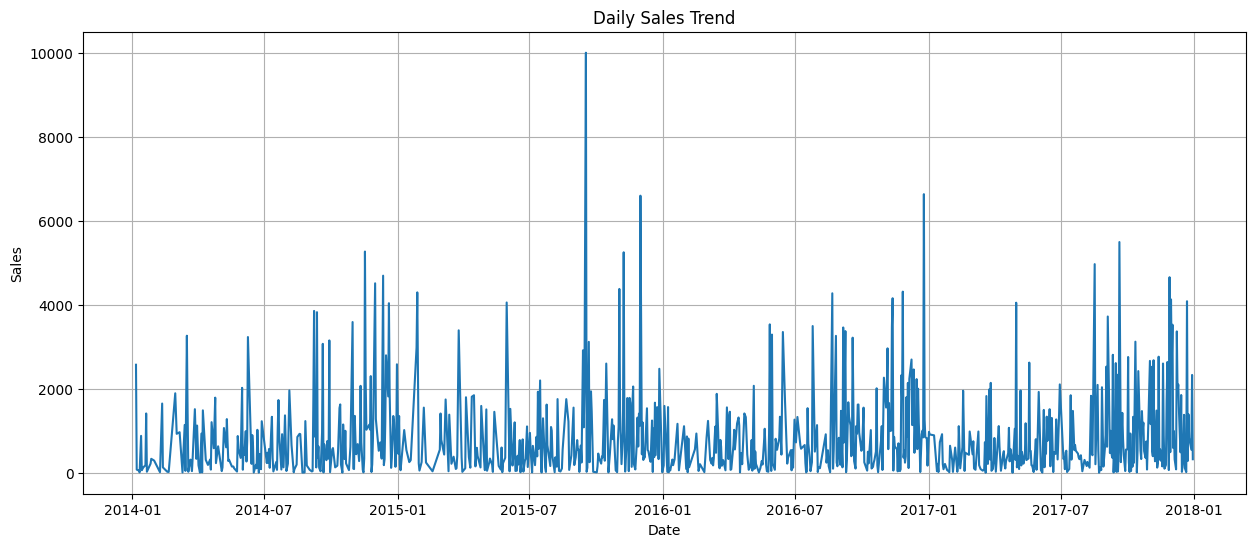

In [13]:
plt.figure(figsize=(15,6))

plt.plot(
    sales_df['Order Date'],
    sales_df['Sales']
)

plt.title("Daily Sales Trend")

plt.xlabel("Date")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

## Monthly Sales Trends

/tmp/ipykernel_6345/2965082340.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = sales_df.resample(


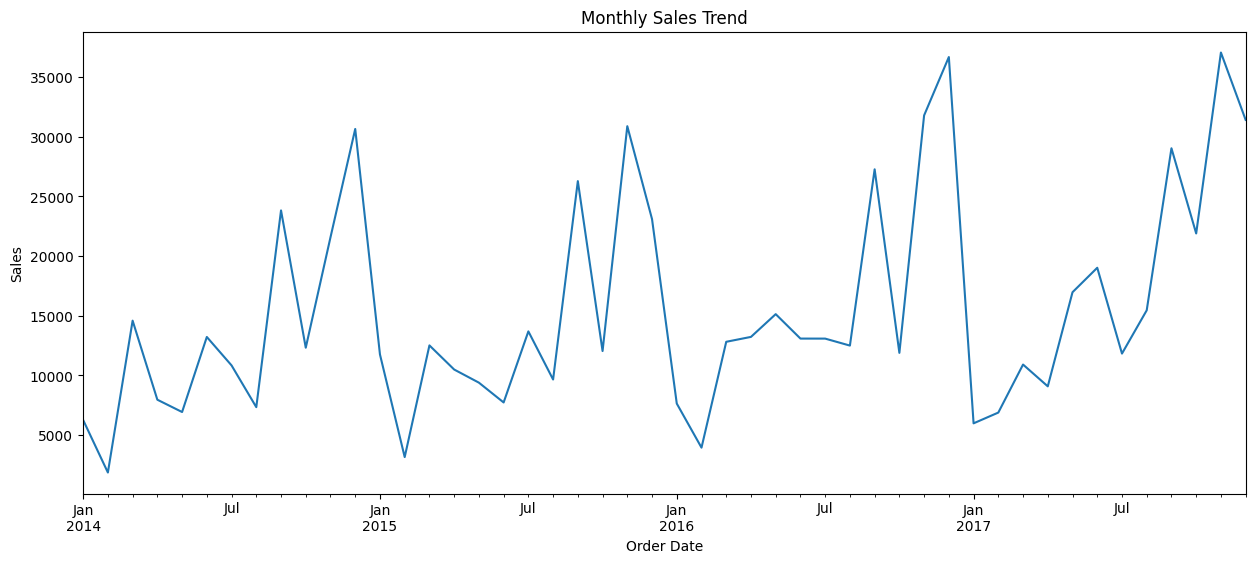

In [14]:
monthly_sales = sales_df.resample(
    'M',
    on='Order Date'
)['Sales'].sum()

plt.figure(figsize=(15,6))

monthly_sales.plot()

plt.title("Monthly Sales Trend")

plt.ylabel("Sales")

plt.show()

## Sales Distribution

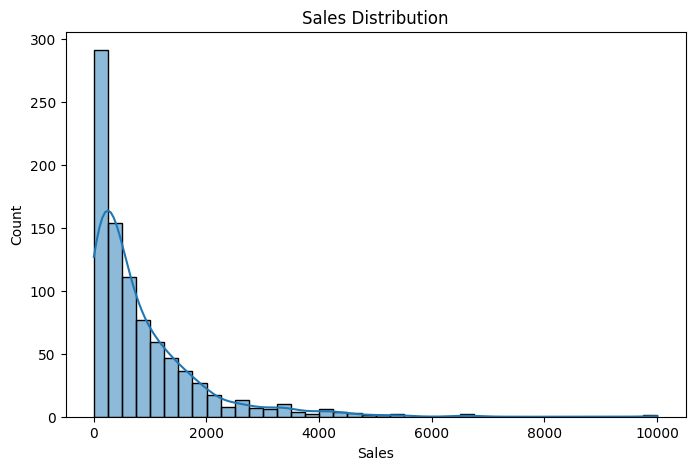

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(
    sales_df['Sales'],
    bins=40,
    kde=True
)

plt.title("Sales Distribution")

plt.show()

## Top 10 States by Sales

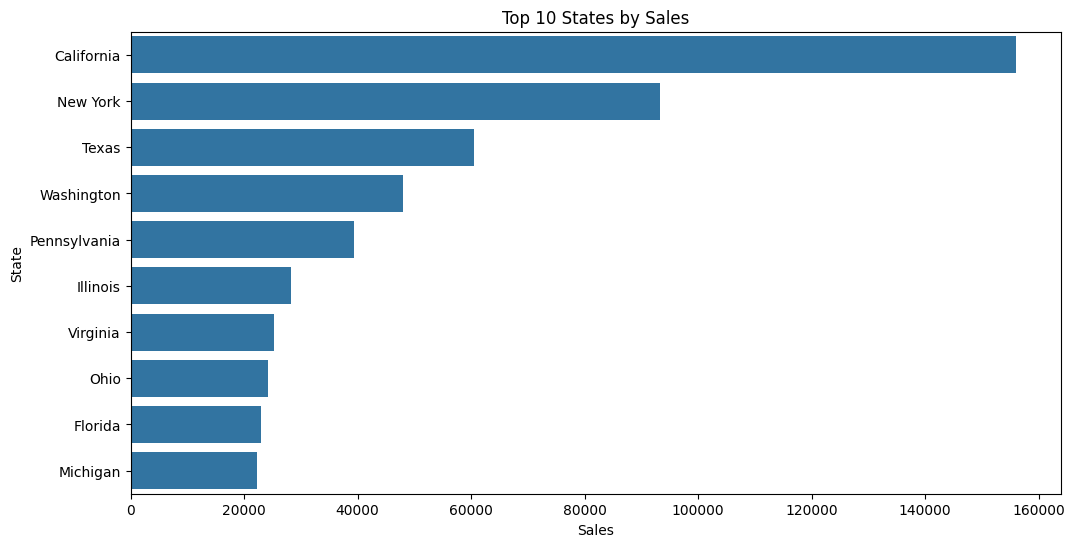

In [17]:
top_states = df.groupby(
    'State'
)['Sales'].sum().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_states.values,
    y=top_states.index
)

plt.title("Top 10 States by Sales")

plt.xlabel("Sales")

plt.show()

## Correlation Heatmap

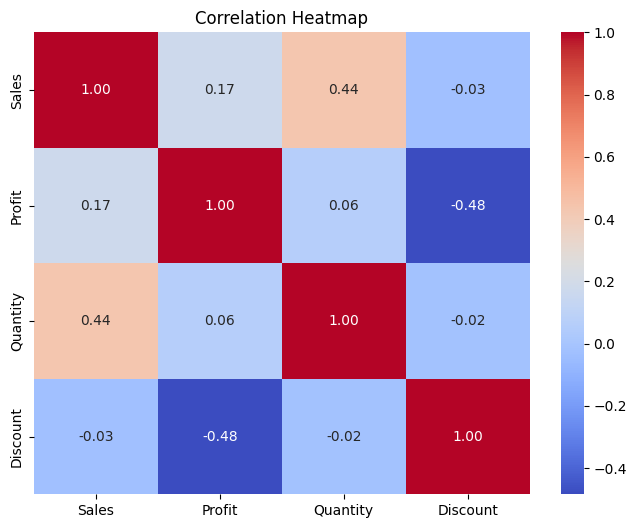

In [18]:
numeric_cols = [
    'Sales',
    'Profit',
    'Quantity',
    'Discount'
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

## Data Scaling

In [19]:
sales = sales_df['Sales'].values.reshape(-1,1)

scaler = MinMaxScaler()

sales_scaled = scaler.fit_transform(sales)

## Creating Sequences

In [20]:
def create_sequences(data, sequence_length):

    X = []
    y = []

    for i in range(len(data)-sequence_length):

        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])

    return np.array(X), np.array(y)


sequence_length = 30

X, y = create_sequences(
    sales_scaled,
    sequence_length
)

print(X.shape)
print(y.shape)

(859, 30, 1)
(859, 1)


## Train Test Split

In [21]:
split = int(len(X)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

## Building RNN Model

In [22]:
model = Sequential()

model.add(
    SimpleRNN(
        64,
        return_sequences=True,
        input_shape=(X_train.shape[1],1)
    )
)

model.add(Dropout(0.2))

model.add(SimpleRNN(32))

model.add(Dropout(0.2))

model.add(Dense(16,activation='relu'))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 30, 64)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,873 (30.75 KB)

 Trainable params: 7,873 (30.75 KB)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [25]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0122 - val_loss: 0.0053
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0109 - val_loss: 0.0050
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0115 - val_loss: 0.0049
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0113 - val_loss: 0.0051
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0114 - val_loss: 0.0050
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0112 - val_loss: 0.0050
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0111 - val_loss: 0.0050
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0111 - val_loss: 0.0049
Epoch 9/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0107 - val_loss: 0.0050
Epoch 10/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0108 - val_loss: 0.0049
Epoch 11/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0109 - val_loss: 0.0049
Epoch 12/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0

## Learning Curve

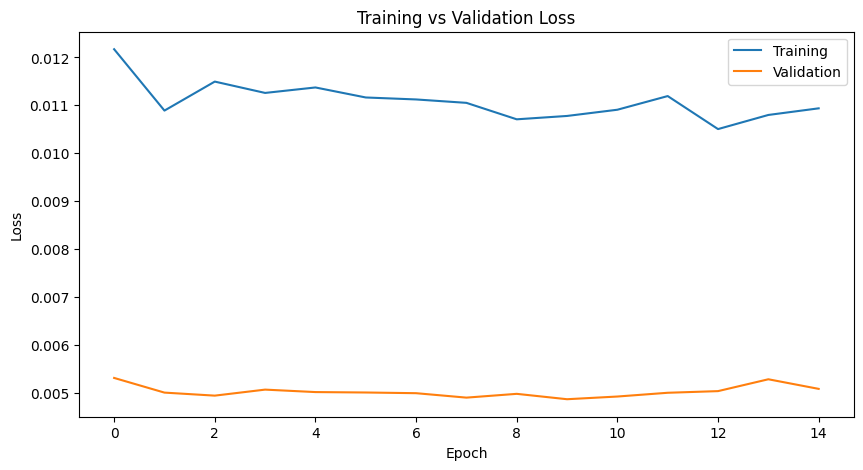

In [26]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    'Training',
    'Validation'
])

plt.show()

## Predictions

In [27]:
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)

y_test_actual = scaler.inverse_transform(y_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step


## Actual vs Predicted Sales

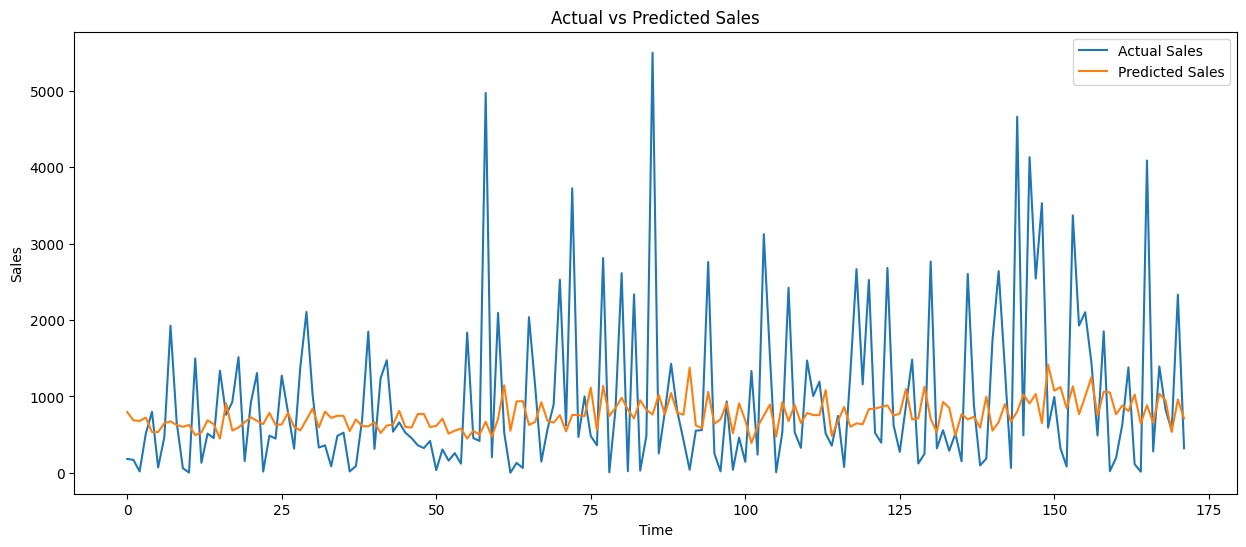

In [28]:
plt.figure(figsize=(15,6))

plt.plot(
    y_test_actual,
    label='Actual Sales'
)

plt.plot(
    predictions,
    label='Predicted Sales'
)

plt.title("Actual vs Predicted Sales")

plt.xlabel("Time")

plt.ylabel("Sales")

plt.legend()

plt.show()

## Evaluation Metrics

In [29]:
mae = mean_absolute_error(
    y_test_actual,
    predictions
)

mse = mean_squared_error(
    y_test_actual,
    predictions
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test_actual,
    predictions
)

mape = np.mean(
    np.abs(
        (y_test_actual - predictions)
        / y_test_actual
    )
) * 100

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)
print("MAPE :", mape)

MAE : 737.3169444046375
MSE : 1158356.6885097893
RMSE : 1076.2698028421078
R2 Score : -0.03300202982563483
MAPE : 594.652129133135


## Residual Plot

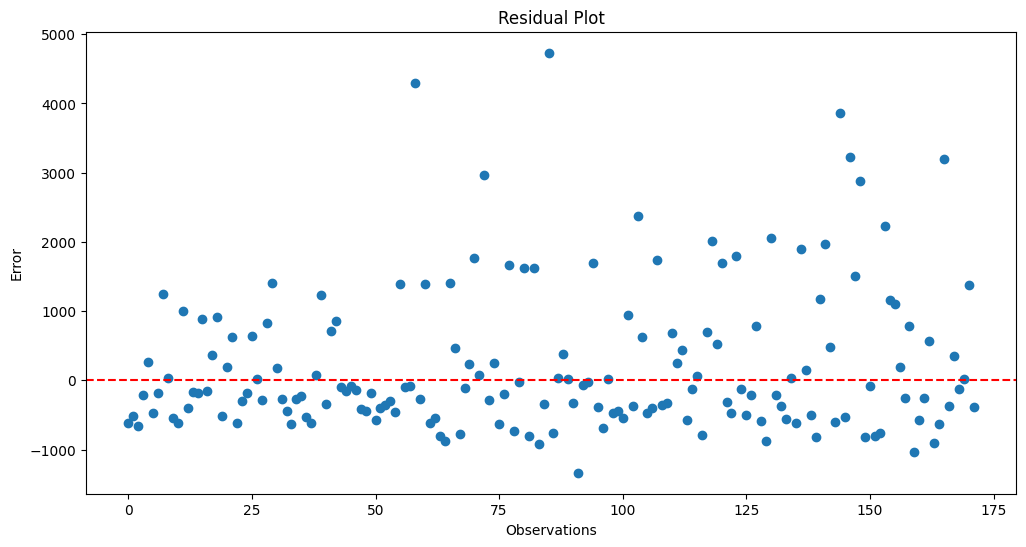

In [30]:
residuals = y_test_actual.flatten() - predictions.flatten()

plt.figure(figsize=(12,6))

plt.scatter(
    range(len(residuals)),
    residuals
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.title("Residual Plot")

plt.xlabel("Observations")
plt.ylabel("Error")

plt.show()

## Metrics Bar Chart

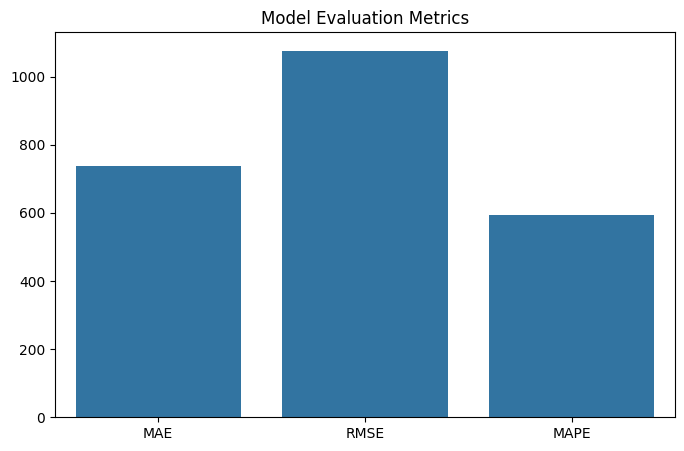

In [31]:
metrics = {
    'MAE': mae,
    'RMSE': rmse,
    'MAPE': mape
}

plt.figure(figsize=(8,5))

sns.barplot(
    x=list(metrics.keys()),
    y=list(metrics.values())
)

plt.title("Model Evaluation Metrics")

plt.show()

## Forecast for Next 30 Days

In [32]:
last_sequence = sales_scaled[-30:]

future_sales = []

current_sequence = last_sequence.copy()

for _ in range(30):

    pred = model.predict(
        current_sequence.reshape(1,30,1),
        verbose=0
    )

    future_sales.append(pred[0][0])

    current_sequence = np.append(
        current_sequence[1:],
        pred
    )

future_sales = np.array(
    future_sales
).reshape(-1,1)

future_sales = scaler.inverse_transform(
    future_sales
)

## Future Sales Forecast Graph

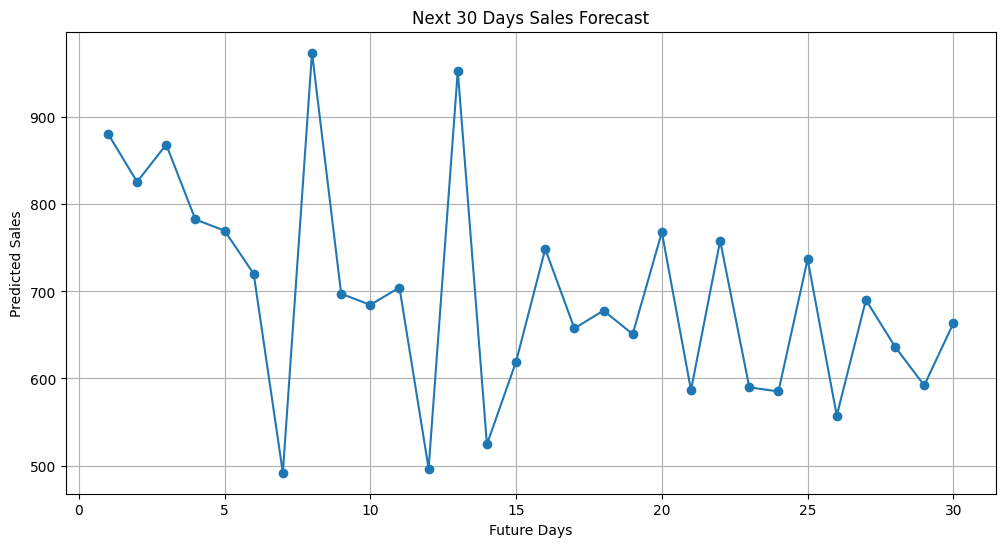

In [33]:
plt.figure(figsize=(12,6))

plt.plot(
    range(1,31),
    future_sales,
    marker='o'
)

plt.title("Next 30 Days Sales Forecast")

plt.xlabel("Future Days")
plt.ylabel("Predicted Sales")

plt.grid(True)

plt.show()

## Model Summary

- The model achieved a Mean Absolute Error (MAE) of 737.32, indicating an average prediction deviation of approximately 737 sales units.
- The Root Mean Squared Error (RMSE) of 1076.27 suggests the presence of relatively large prediction errors.
- The R² Score of -0.033 indicates that the model did not effectively capture the underlying sales patterns and performed worse than a simple baseline prediction using the mean sales value.
- The high MAPE value (594.65%) indicates substantial percentage prediction errors, likely due to large fluctuations and low sales values in certain periods.
- The model was able to learn some general sales trends but showed limited forecasting accuracy.
- Performance can be improved through feature engineering, hyperparameter tuning, seasonal feature extraction, and the use of advanced architectures such as LSTM or GRU networks.
- Additional business-related variables such as promotions, holidays, customer behavior, and regional factors may further enhance forecasting performance.